# Volatility Modelling in Continuous Time
**MA52114 Coursework, Option C**

This notebook is the runnable code that accompanies the written report. The report contains all theoretical exposition, parameter discussion and analysis of results. Comments here are kept code-focused. The majority of figures produced by the cells below are referenced directly in the report however two exploratory figures (the call price cross-sections in Task 2 and the implied volatility smile slices in Task 3) are generated for completeness but not included in the PDF, as noted in the markdown cells immediately preceding them.

Pipeline:
1. Heston model setup, simulation and Monte Carlo validation.
2. Build the 50x50 European call price surface.
3. Invert to an implied volatility surface.
4. Build the Dupire local volatility surface and price an off-grid option.
5. Re-price the same option along simulated paths without recalibrating Dupire.
6. Calibrate a blind Heston model to the noisy price surface and compare.

In [1]:
import time
import warnings

import QuantLib as ql
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.optimize import brentq, least_squares
from scipy.stats import norm
from scipy.interpolate import RegularGridInterpolator
from scipy.linalg import solve_banded

np.random.seed(42)

# Coursework parameters (fixed throughout)
S0, r = 200.0, 0.05
nu0, kappa, theta, xi, rho = 0.04, 1.5, 0.04, 0.3, -0.7

## Task 1: Heston model setup, simulation and validation

In [2]:
def validate_heston_parameters(S0, nu0, kappa, theta, xi, rho):
    """Raise ValueError on inadmissible Heston parameters; warn if Feller violated."""
    if S0 <= 0:
        raise ValueError(f"S0 must be positive, got {S0}.")
    if nu0 < 0:
        raise ValueError(f"nu0 must be non-negative, got {nu0}.")
    if kappa <= 0:
        raise ValueError(f"kappa must be positive, got {kappa}.")
    if theta <= 0:
        raise ValueError(f"theta must be positive, got {theta}.")
    if xi <= 0:
        raise ValueError(f"xi must be positive, got {xi}.")
    if not -1.0 <= rho <= 1.0:
        raise ValueError(f"rho must lie in [-1, 1], got {rho}.")
    if 2 * kappa * theta <= xi ** 2:
        warnings.warn(
            f"Feller condition violated: 2*kappa*theta={2*kappa*theta:.4f} "
            f"<= xi^2={xi**2:.4f}. Variance may reach zero.",
            RuntimeWarning,
        )


validate_heston_parameters(S0, nu0, kappa, theta, xi, rho)
print(f"Feller: 2*kappa*theta = {2*kappa*theta:.3f} > xi^2 = {xi**2:.3f}  -> satisfied")

Feller: 2*kappa*theta = 0.120 > xi^2 = 0.090  -> satisfied


In [3]:
def build_heston_process(S0, r, nu0, kappa, theta, xi, rho,
                          eval_date=ql.Date(1, ql.January, 2025)):
    """Construct a QuantLib HestonProcess with a flat zero curve and no dividends."""
    validate_heston_parameters(S0, nu0, kappa, theta, xi, rho)
    ql.Settings.instance().evaluationDate = eval_date

    day_count = ql.Actual365Fixed()
    rate_handle = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, r, day_count))
    div_handle = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, 0.0, day_count))
    spot_handle = ql.QuoteHandle(ql.SimpleQuote(S0))

    return ql.HestonProcess(
        rate_handle, div_handle, spot_handle,
        nu0, kappa, theta, xi, rho,
    )


process = build_heston_process(S0, r, nu0, kappa, theta, xi, rho)

In [4]:
def simulate_heston_paths(process, T, n_steps, n_paths, seed=42):
    """Simulate Heston paths via QuantLib's GaussianMultiPathGenerator (Cholesky + Euler).

    Returns (t, S, V) where S, V have shape (n_paths, n_steps + 1).
    """
    if T <= 0 or n_steps < 1 or n_paths < 1:
        raise ValueError("T must be positive and n_steps, n_paths >= 1.")

    times = ql.TimeGrid(T, n_steps)
    dimension = process.factors() * n_steps
    uniform_rng = ql.UniformRandomSequenceGenerator(dimension, ql.UniformRandomGenerator(seed))
    gaussian_rng = ql.GaussianRandomSequenceGenerator(uniform_rng)
    path_generator = ql.GaussianMultiPathGenerator(process, list(times), gaussian_rng, False)

    S = np.empty((n_paths, n_steps + 1))
    V = np.empty((n_paths, n_steps + 1))
    for i in range(n_paths):
        sample_path = path_generator.next().value()
        for j in range(n_steps + 1):
            S[i, j] = sample_path[0][j]
            V[i, j] = sample_path[1][j]

    t = np.array([times[k] for k in range(len(times))])
    return t, S, V


T_sim, n_steps, n_paths = 2.0, 500, 5000
t, S_paths, V_paths = simulate_heston_paths(process, T_sim, n_steps, n_paths)

print(f"Simulated {n_paths} paths over [0, {T_sim}] with {n_steps} steps.")
print(f"E[S_T]  = {S_paths[:, -1].mean():7.2f}   (theoretical: S0*exp(rT) = {S0 * np.exp(r * T_sim):.2f})")
print(f"E[nu_T] = {V_paths[:, -1].mean():7.4f}   (theoretical: theta = {theta})")

Simulated 5000 paths over [0, 2.0] with 500 steps.
E[S_T]  =  221.24   (theoretical: S0*exp(rT) = 221.03)
E[nu_T] =  0.0397   (theoretical: theta = 0.04)


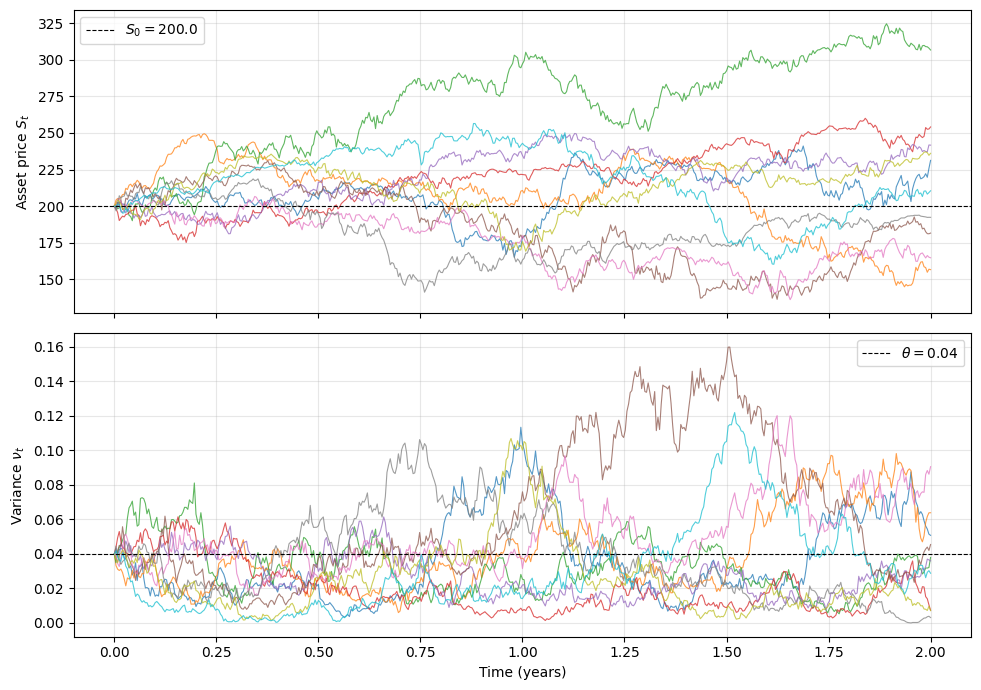

In [5]:
# Sample paths plot (10 paths, S and V)
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
n_show = 10
for i in range(n_show):
    axes[0].plot(t, S_paths[i], lw=0.8, alpha=0.75)
    axes[1].plot(t, V_paths[i], lw=0.8, alpha=0.75)

axes[0].axhline(S0, ls="--", c="k", lw=0.8, label=f"$S_0 = {S0}$")
axes[0].set_ylabel("Asset price $S_t$")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].axhline(theta, ls="--", c="k", lw=0.8, label=fr"$\theta = {theta}$")
axes[1].set_ylabel(r"Variance $\nu_t$")
axes[1].set_xlabel("Time (years)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("heston_sample_paths.png", dpi=300)
plt.show()

In [6]:
def heston_call_price_analytic(K, T, process):
    """European call under Heston via QuantLib's AnalyticHestonEngine (Fourier inversion)."""
    if K <= 0 or T <= 0:
        raise ValueError(f"Need K > 0 and T > 0, got K={K}, T={T}.")
    eval_date = ql.Settings.instance().evaluationDate
    maturity = eval_date + ql.Period(int(round(T * 365)), ql.Days)
    payoff = ql.PlainVanillaPayoff(ql.Option.Call, K)
    exercise = ql.EuropeanExercise(maturity)
    option = ql.VanillaOption(payoff, exercise)
    option.setPricingEngine(ql.AnalyticHestonEngine(ql.HestonModel(process)))
    return option.NPV()


# Cross-validation: MC vs analytic at six (K, T) points
print(f"{'K':>6} {'T':>5} {'MC':>10} {'Analytic':>10} {'Rel err':>9}")
print("-" * 45)
for T_test in [0.5, 1.0]:
    idx = int(T_test / T_sim * n_steps)
    S_T = S_paths[:, idx]
    discount = np.exp(-r * T_test)
    for K in [180, 200, 220]:
        mc = discount * np.maximum(S_T - K, 0).mean()
        analytic = heston_call_price_analytic(K, T_test, process)
        rel = abs(mc - analytic) / analytic * 100
        print(f"{K:>6.0f} {T_test:>5.1f} {mc:>10.4f} {analytic:>10.4f} {rel:>8.2f}%")

     K     T         MC   Analytic   Rel err
---------------------------------------------
   180   0.5    27.7874    27.6540     0.48%
   200   0.5    13.8285    13.6295     1.46%
   220   0.5     4.8690     4.6515     4.67%
   180   1.0    34.3282    34.2139     0.33%
   200   1.0    20.8672    20.7237     0.69%
   220   1.0    10.7154    10.6359     0.75%


## Task 2: 50x50 European call price surface

In [7]:
def build_price_surface_grid(T_min, T_max, n_T, K_min, K_max, n_K):
    """Uniform (T, K) grids with input validation."""
    if T_min <= 0 or T_max <= T_min or K_min <= 0 or K_max <= K_min:
        raise ValueError("Need 0 < T_min < T_max and 0 < K_min < K_max.")
    if n_T < 2 or n_K < 2:
        raise ValueError("Grid must have at least 2 points in each dimension.")
    return np.linspace(T_min, T_max, n_T), np.linspace(K_min, K_max, n_K)


T_grid, K_grid = build_price_surface_grid(
    T_min=0.05, T_max=2.0, n_T=50,
    K_min=0.6 * S0, K_max=1.4 * S0, n_K=50,
)

print(f"Maturity grid: {len(T_grid)} points in [{T_grid[0]:.3f}, {T_grid[-1]:.3f}] years"
      f" (step ~{(T_grid[1] - T_grid[0]) * 365:.1f} days)")
print(f"Strike grid:   {len(K_grid)} points in [{K_grid[0]:.1f}, {K_grid[-1]:.1f}]"
      f" (moneyness {K_grid[0]/S0:.2f} to {K_grid[-1]/S0:.2f})")

Maturity grid: 50 points in [0.050, 2.000] years (step ~14.5 days)
Strike grid:   50 points in [120.0, 280.0] (moneyness 0.60 to 1.40)


In [8]:
def compute_price_surface(process, T_grid, K_grid, option_type=ql.Option.Call):
    """Price a (T_grid x K_grid) surface using a single AnalyticHestonEngine.

    QuantLib operates on calendar dates, so each T is rounded to a whole number
    of days. The actual maturity grid used by the pricer is returned alongside
    the prices, so downstream IV inversion and Dupire derivatives use the same T.
    """
    if not isinstance(process, ql.HestonProcess):
        raise TypeError(f"process must be a ql.HestonProcess, got {type(process).__name__}.")
    if option_type not in (ql.Option.Call, ql.Option.Put):
        raise ValueError("option_type must be ql.Option.Call or ql.Option.Put.")
    if np.any(T_grid <= 0) or np.any(K_grid <= 0):
        raise ValueError("T_grid and K_grid must be strictly positive.")

    eval_date = ql.Settings.instance().evaluationDate
    engine = ql.AnalyticHestonEngine(ql.HestonModel(process))

    n_T, n_K = len(T_grid), len(K_grid)
    prices = np.empty((n_T, n_K))
    T_actual = np.empty(n_T)

    for i, T in enumerate(T_grid):
        n_days = int(round(T * 365))
        if n_days < 1:
            raise ValueError(f"Maturity T={T} rounds to less than 1 day.")
        T_actual[i] = n_days / 365.0
        maturity = eval_date + ql.Period(n_days, ql.Days)
        exercise = ql.EuropeanExercise(maturity)
        for j, K in enumerate(K_grid):
            payoff = ql.PlainVanillaPayoff(option_type, K)
            option = ql.VanillaOption(payoff, exercise)
            option.setPricingEngine(engine)
            prices[i, j] = option.NPV()

    return prices, T_actual


t0 = time.time()
prices_raw, T_grid = compute_price_surface(process, T_grid, K_grid)
print(f"Computed {prices_raw.size} prices in {time.time() - t0:.2f} s "
      f"({(time.time() - t0) / prices_raw.size * 1000:.2f} ms each)")
print(f"Price range: [{prices_raw.min():.4f}, {prices_raw.max():.4f}]")

Computed 2500 prices in 0.10 s (0.04 ms each)
Price range: [-0.0000, 92.3555]


In [9]:
def check_no_arbitrage(prices, T_grid, K_grid, S0, r, tol=1e-8):
    """Count numerical no-arbitrage violations (positivity, bounds, monotonicity, convexity)."""
    if prices.shape != (len(T_grid), len(K_grid)):
        raise ValueError(f"prices shape {prices.shape} does not match grid.")
    lower_bnd = np.maximum(S0 - K_grid[None, :] * np.exp(-r * T_grid[:, None]), 0.0)
    return {
        "lower_bound":   int(np.sum(prices < lower_bnd - tol)),
        "upper_bound":   int(np.sum(prices > S0 + tol)),
        "negative":      int(np.sum(prices < -tol)),
        "monotone_in_K": int(np.sum(np.diff(prices, axis=1) > tol)),
        "monotone_in_T": int(np.sum(np.diff(prices, axis=0) < -tol)),
        "convex_in_K":   int(np.sum(np.diff(prices, n=2, axis=1) < -tol)),
    }


def repair_surface(prices, T_grid, K_grid, S0, r):
    """Clip prices to the no-arbitrage band [intrinsic, S0]. Returns (repaired, counts)."""
    if prices.shape != (len(T_grid), len(K_grid)):
        raise ValueError("prices shape does not match grid.")
    lower_bnd = np.maximum(S0 - K_grid[None, :] * np.exp(-r * T_grid[:, None]), 0.0)
    n_repairs = {
        "below_lower_bound": int(np.sum(prices < lower_bnd)),
        "above_upper_bound": int(np.sum(prices > S0)),
    }
    return np.clip(prices, lower_bnd, S0), n_repairs


violations = check_no_arbitrage(prices_raw, T_grid, K_grid, S0, r)
print("Pre-repair violation counts:", violations)

prices, n_repairs = repair_surface(prices_raw, T_grid, K_grid, S0, r)
print(f"Repaired {n_repairs} cells.")

post = check_no_arbitrage(prices, T_grid, K_grid, S0, r)
assert all(v == 0 for v in post.values()), "Repair did not eliminate all violations."
print("All arbitrage checks pass on the repaired surface.")

Pre-repair violation counts: {'lower_bound': 0, 'upper_bound': 0, 'negative': 0, 'monotone_in_K': 0, 'monotone_in_T': 0, 'convex_in_K': 0}
Repaired {'below_lower_bound': 8, 'above_upper_bound': 0} cells.
All arbitrage checks pass on the repaired surface.


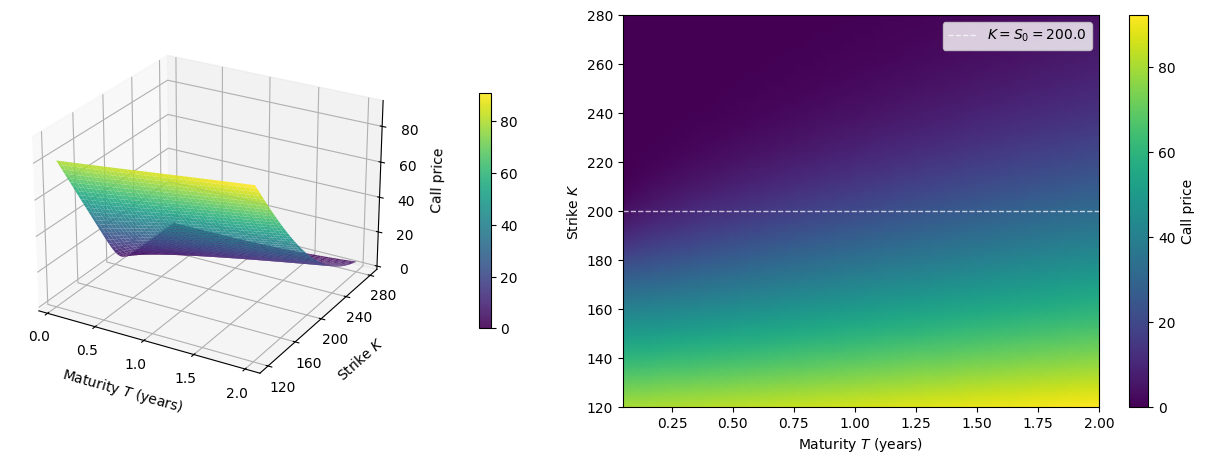

In [10]:
# Heston call price surface plot (3D + heatmap)
fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
T_mesh, K_mesh = np.meshgrid(T_grid, K_grid, indexing="ij")
surf = ax1.plot_surface(T_mesh, K_mesh, prices, cmap="viridis", alpha=0.9, edgecolor="none")
ax1.xaxis.set_major_locator(MaxNLocator(5))
ax1.yaxis.set_major_locator(MaxNLocator(5))
ax1.zaxis.set_major_locator(MaxNLocator(5))
ax1.set_xlabel("Maturity $T$ (years)", labelpad=5)
ax1.set_ylabel("Strike $K$", labelpad=5)
ax1.set_zlabel("Call price", labelpad=5)
ax1.tick_params(axis="x", labelsize=10, pad=1)
ax1.tick_params(axis="y", labelsize=10, pad=1)
ax1.tick_params(axis="z", labelsize=10, pad=4)
ax1.view_init(elev=25, azim=-60)
fig.colorbar(surf, ax=ax1, shrink=0.6, pad=0.13)

ax2 = fig.add_subplot(1, 2, 2)
mesh = ax2.pcolormesh(T_grid, K_grid, prices.T, cmap="viridis", shading="gouraud")
ax2.axhline(S0, color="white", ls="--", lw=1, alpha=0.7, label=f"$K = S_0 = {S0}$")
ax2.set_xlabel("Maturity $T$ (years)")
ax2.set_ylabel("Strike $K$")
ax2.legend(loc="best")
fig.colorbar(mesh, ax=ax2, label="Call price")

plt.tight_layout(pad=2.0)
plt.savefig("heston_price_surface.png", dpi=300, bbox_inches="tight")
plt.show()

*Note: the figure produced by the next cell is generated for exploratory analysis and is not included in the submitted PDF report. It plots the European call price as a function of strike at five selected maturities, providing an alternative view of the same surface visualised in three dimensions and as a heatmap above. The cross-sections confirm the expected shape, that prices are monotonically decreasing in $K$ and the curves shift upwards with longer maturity, but add no information beyond what the previous figure already shows.*

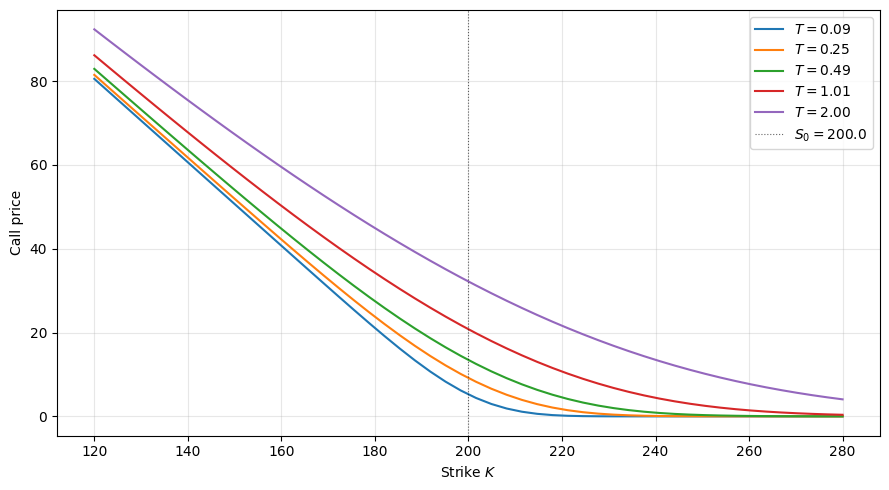

In [11]:
# Cross-section: price vs strike at selected maturities
fig, ax = plt.subplots(figsize=(9, 5))
for T_target in [0.10, 0.25, 0.5, 1.0, 2.0]:
    i = int(np.argmin(np.abs(T_grid - T_target)))
    ax.plot(K_grid, prices[i], lw=1.5, label=f"$T = {T_grid[i]:.2f}$")
ax.axvline(S0, color="k", ls=":", lw=0.8, alpha=0.6, label=f"$S_0 = {S0}$")
ax.set_xlabel("Strike $K$")
ax.set_ylabel("Call price")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("heston_price_cross_sections.png", dpi=300)
plt.show()

## Task 3: Implied volatility surface

In [12]:
def black_scholes_call(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return max(S - K * np.exp(-r * T), 0.0)
    sqrt_T = np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrt_T)
    d2 = d1 - sigma * sqrt_T
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def black_scholes_put(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return max(K * np.exp(-r * T) - S, 0.0)
    sqrt_T = np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrt_T)
    d2 = d1 - sigma * sqrt_T
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


def _implied_vol_from_bs_price(price, S0, K, T, r, bs_pricer,
                               intrinsic, upper_bound,
                               sigma_lower=1e-4, sigma_upper=5.0):
    """Brent-method root finder for implied volatility. Returns NaN on failure."""
    if price < 0 or S0 <= 0 or K <= 0 or T <= 0:
        raise ValueError("Inputs must be positive (price >= 0).")
    if sigma_lower <= 0 or sigma_upper <= sigma_lower:
        raise ValueError("Need 0 < sigma_lower < sigma_upper.")

    # Cells at or beyond the no-arbitrage band carry no information about IV
    if price <= intrinsic + 1e-10 or price >= upper_bound - 1e-10:
        return float("nan")
    try:
        return brentq(
            lambda sigma: bs_pricer(S0, K, T, r, sigma) - price,
            sigma_lower, sigma_upper, xtol=1e-10, maxiter=200,
        )
    except (ValueError, RuntimeError):
        return float("nan")


def implied_volatility_call(price, S0, K, T, r):
    intrinsic = max(S0 - K * np.exp(-r * T), 0.0)
    return _implied_vol_from_bs_price(
        price, S0, K, T, r, black_scholes_call,
        intrinsic=intrinsic, upper_bound=S0,
    )


def implied_volatility_put(price, S0, K, T, r):
    intrinsic = max(K * np.exp(-r * T) - S0, 0.0)
    return _implied_vol_from_bs_price(
        price, S0, K, T, r, black_scholes_put,
        intrinsic=intrinsic, upper_bound=K * np.exp(-r * T),
    )


def implied_volatility_otm(call_price, S0, K, T, r):
    """Invert the OTM side: call directly when K >= S0, otherwise convert to a put via parity.

    Deep ITM options have very little time value, so tiny pricing errors blow up
    in the inversion. The OTM convention keeps the inverter away from that regime.
    """
    if K >= S0:
        return implied_volatility_call(call_price, S0, K, T, r)
    put_price = call_price - S0 + K * np.exp(-r * T)
    return implied_volatility_put(put_price, S0, K, T, r)

In [13]:
def compute_iv_surface(prices, T_grid, K_grid, S0, r):
    """Invert a call price surface for IV using the OTM convention."""
    iv = np.full(prices.shape, np.nan)
    for i, T in enumerate(T_grid):
        for j, K in enumerate(K_grid):
            iv[i, j] = implied_volatility_otm(prices[i, j], S0, K, T, r)
    return iv, int(np.isnan(iv).sum())


iv_surface, n_failed = compute_iv_surface(prices, T_grid, K_grid, S0, r)
valid = iv_surface[~np.isnan(iv_surface)]

print(f"IV surface: {iv_surface.size - n_failed}/{iv_surface.size} cells inverted "
      f"({n_failed} failures in deep-OTM/short-T corner).")
print(f"  range: [{valid.min()*100:.2f}%, {valid.max()*100:.2f}%], "
      f"mean = {valid.mean()*100:.2f}%")

IV surface: 2482/2500 cells inverted (18 failures in deep-OTM/short-T corner).
  range: [14.81%, 29.87%], mean = 20.29%


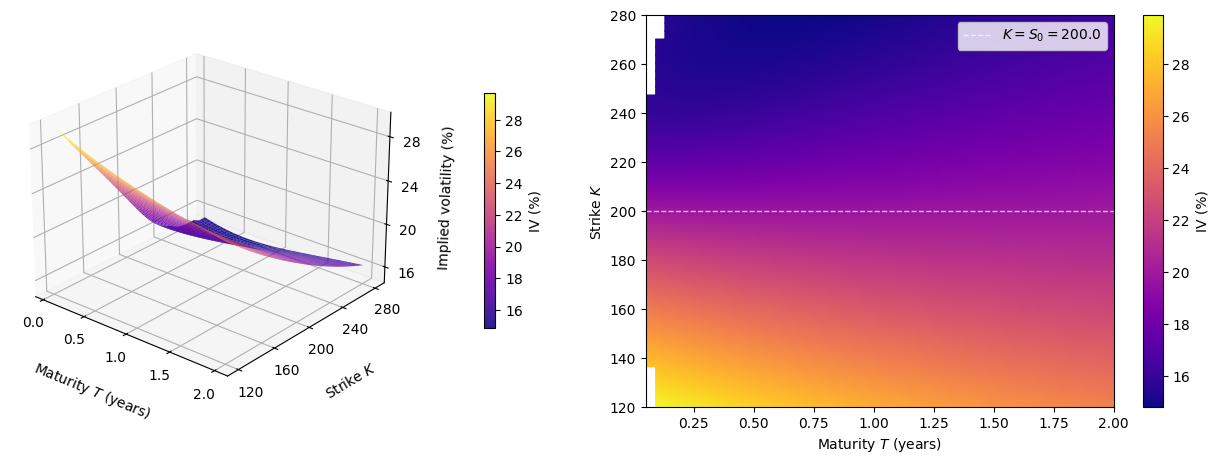

In [14]:
# IV surface plot (3D + heatmap)
fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
T_mesh, K_mesh = np.meshgrid(T_grid, K_grid, indexing="ij")
surf = ax1.plot_surface(T_mesh, K_mesh, iv_surface * 100, cmap="plasma", alpha=0.9, edgecolor="none")
ax1.xaxis.set_major_locator(MaxNLocator(5))
ax1.yaxis.set_major_locator(MaxNLocator(5))
ax1.zaxis.set_major_locator(MaxNLocator(5))
ax1.set_xlabel("Maturity $T$ (years)", labelpad=10)
ax1.set_ylabel("Strike $K$", labelpad=10)
ax1.set_zlabel("Implied volatility (%)", labelpad=4)
ax1.tick_params(axis="x", labelsize=10, pad=1)
ax1.tick_params(axis="y", labelsize=10, pad=1)
ax1.tick_params(axis="z", labelsize=10, pad=1)
# ax1.set_title("Heston implied volatility surface", pad=15)
ax1.view_init(elev=25, azim=-50)
fig.colorbar(surf, ax=ax1, shrink=0.6, pad=0.14, label="IV (%)")

ax2 = fig.add_subplot(1, 2, 2)
mesh = ax2.pcolormesh(T_grid, K_grid, iv_surface.T * 100, cmap="plasma", shading="gouraud")
ax2.axhline(S0, color="white", ls="--", lw=1, alpha=0.7, label=f"$K = S_0 = {S0}$")
ax2.set_xlabel("Maturity $T$ (years)")
ax2.set_ylabel("Strike $K$")
ax2.legend(loc="best")
fig.colorbar(mesh, ax=ax2, label="IV (%)")

plt.tight_layout(pad=2.0)
plt.savefig("heston_iv_surface.png", dpi=300, bbox_inches="tight")
plt.show()

*Note: the figure produced by the next cell is generated for exploratory analysis and is not included in the submitted PDF report. The left panel shows the implied volatility smile at five maturities (illustrating the smile flattening with $T$), and the right panel shows the at-the-money term structure converging to $\sqrt{\theta} = 20\%$ as $T$ increases. These features are discussed in the report text but are not duplicated as figures, since the surface visualisation already captures them in two dimensions.*

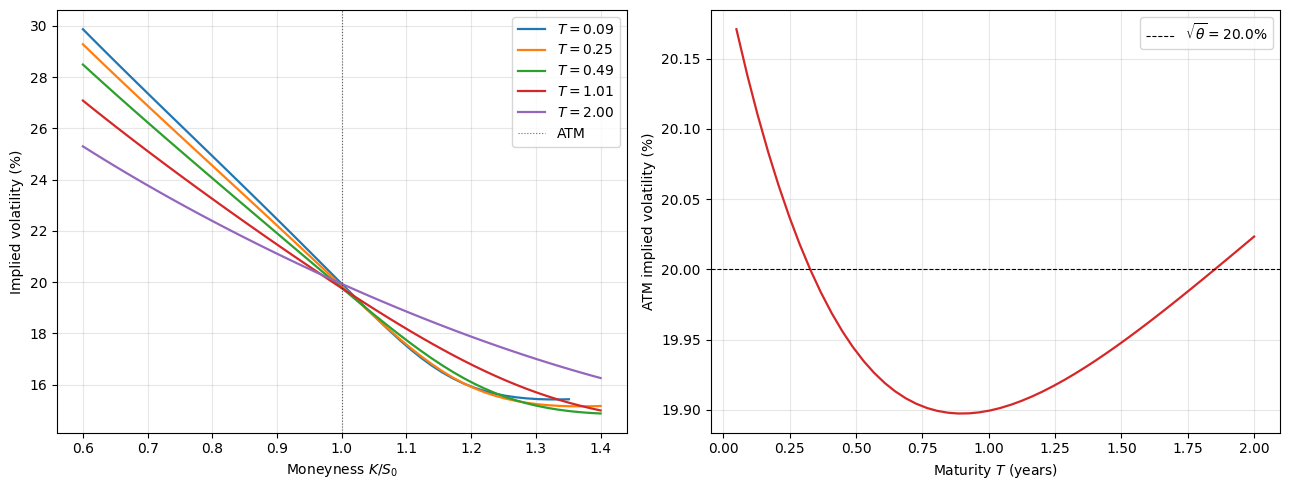

In [15]:
# Smile slices and ATM term structure
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for T_target in [0.10, 0.25, 0.5, 1.0, 2.0]:
    i = int(np.argmin(np.abs(T_grid - T_target)))
    axes[0].plot(K_grid / S0, iv_surface[i] * 100, lw=1.6, label=f"$T = {T_grid[i]:.2f}$")
axes[0].axvline(1.0, c="k", ls=":", lw=0.8, alpha=0.6, label="ATM")
axes[0].set_xlabel("Moneyness $K / S_0$")
axes[0].set_ylabel("Implied volatility (%)")
axes[0].legend(); axes[0].grid(alpha=0.3)

j_atm = int(np.argmin(np.abs(K_grid - S0)))
axes[1].plot(T_grid, iv_surface[:, j_atm] * 100, lw=1.6, color="C3")
axes[1].axhline(np.sqrt(theta) * 100, c="k", ls="--", lw=0.8,
                label=fr"$\sqrt{{\theta}} = {np.sqrt(theta) * 100:.1f}\%$")
axes[1].set_xlabel("Maturity $T$ (years)")
axes[1].set_ylabel("ATM implied volatility (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("heston_iv_smiles.png", dpi=300)
plt.show()

## Task 4: Dupire local volatility and off-grid pricing

In [16]:
def call_surface_derivatives(prices, T_grid, K_grid):
    """Central FD derivatives dC/dT, dC/dK, d2C/dK2 on the (T, K) grid."""
    if prices.shape != (len(T_grid), len(K_grid)):
        raise ValueError("prices shape does not match grid.")
    if np.any(np.gradient(T_grid) <= 0) or np.any(np.gradient(K_grid) <= 0):
        raise ValueError("T_grid and K_grid must be strictly increasing.")

    dC_dT = np.gradient(prices, T_grid, axis=0, edge_order=2)
    dC_dK = np.gradient(prices, K_grid, axis=1, edge_order=2)
    d2C_dK2 = np.gradient(dC_dK, K_grid, axis=1, edge_order=2)
    return dC_dT, dC_dK, d2C_dK2


def build_local_vol_surface(prices, T_grid, K_grid, r, denom_floor=1e-8):
    """Dupire local vol from FD derivatives, with defensive masking.

    Cells with denominator |d2C/dK2| < denom_floor or non-positive local variance
    are replaced by NaN. The boundary ring is also discarded since one-sided
    differences are markedly less accurate.
    """
    if denom_floor <= 0:
        raise ValueError("denom_floor must be positive.")

    dC_dT, dC_dK, d2C_dK2 = call_surface_derivatives(prices, T_grid, K_grid)
    K_mesh = K_grid[None, :]
    numerator = dC_dT + r * K_mesh * dC_dK
    denominator = 0.5 * K_mesh ** 2 * d2C_dK2

    with np.errstate(divide="ignore", invalid="ignore"):
        local_var = np.where(np.abs(denominator) > denom_floor,
                             numerator / denominator, np.nan)

    local_var[0, :]  = np.nan
    local_var[-1, :] = np.nan
    local_var[:, 0]  = np.nan
    local_var[:, -1] = np.nan
    local_var = np.where(local_var > 0, local_var, np.nan)
    return np.sqrt(local_var)


local_vol_surface = build_local_vol_surface(prices, T_grid, K_grid, r)
valid = local_vol_surface[~np.isnan(local_vol_surface)]
print(f"Local vol surface: {valid.size}/{local_vol_surface.size} valid cells, "
      f"range [{valid.min()*100:.2f}%, {valid.max()*100:.2f}%], mean {valid.mean()*100:.2f}%")

Local vol surface: 2304/2500 valid cells, range [12.64%, 95.87%], mean 21.35%


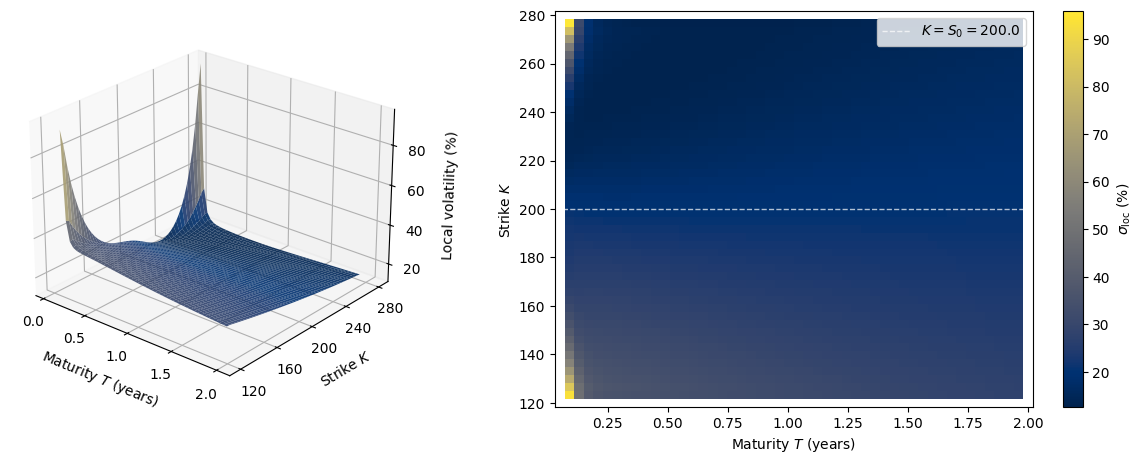

In [17]:
# Local vol surface plot (3D + heatmap)
fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
T_mesh, K_mesh = np.meshgrid(T_grid, K_grid, indexing="ij")
ax1.plot_surface(T_mesh, K_mesh, local_vol_surface * 100,
                 cmap="cividis", alpha=0.9, edgecolor="none")
ax1.xaxis.set_major_locator(MaxNLocator(5))
ax1.yaxis.set_major_locator(MaxNLocator(5))
ax1.zaxis.set_major_locator(MaxNLocator(5))
ax1.set_xlabel("Maturity $T$ (years)", labelpad=4)
ax1.set_ylabel("Strike $K$", labelpad=4)
ax1.set_zlabel("Local volatility (%)", labelpad=4)
ax1.tick_params(axis="x", labelsize=10, pad=1)
ax1.tick_params(axis="y", labelsize=10, pad=1)
ax1.tick_params(axis="z", labelsize=10, pad=2)
ax1.view_init(elev=25, azim=-50)

ax2 = fig.add_subplot(1, 2, 2)
mesh = ax2.pcolormesh(T_grid, K_grid, local_vol_surface.T * 100,
                      cmap="cividis", shading="auto")
ax2.axhline(S0, color="white", ls="--", lw=1, alpha=0.7, label=f"$K = S_0 = {S0}$")
ax2.set_xlabel("Maturity $T$ (years)")
ax2.set_ylabel("Strike $K$")
ax2.legend(loc="best")
fig.colorbar(mesh, ax=ax2, label=r"$\sigma_{\mathrm{loc}}$ (%)")

plt.tight_layout(pad=2.0)
plt.savefig("local_vol_surface.png", dpi=300)
plt.show()

In [18]:
def make_local_vol_interpolator(local_vol_surface, T_grid, K_grid):
    """Bilinear interpolator sigma_loc(t, S) with NaN forward-fill and edge clamping."""
    filled = local_vol_surface.copy()
    if np.isnan(filled).all():
        raise ValueError("Local vol surface is entirely NaN.")
    global_mean = np.nanmean(filled)
    for i in range(filled.shape[0]):
        row = filled[i]
        if np.isnan(row).all():
            filled[i] = global_mean
            continue
        idx = np.where(~np.isnan(row))[0]
        filled[i] = np.interp(np.arange(len(row)), idx, row[idx])
    filled = np.where(np.isnan(filled), global_mean, filled)

    interp = RegularGridInterpolator(
        (T_grid, K_grid), filled, bounds_error=False, fill_value=None,
    )

    def sigma_loc(t, S):
        t_clipped = np.clip(t, T_grid[0], T_grid[-1])
        S_clipped = np.clip(S, K_grid[0], K_grid[-1])
        pts = np.column_stack([np.broadcast_to(t_clipped, S_clipped.shape).ravel(),
                               S_clipped.ravel()])
        return interp(pts).reshape(np.shape(S))

    return sigma_loc


def price_call_dupire_pde(K_star, T_star, S0, r, sigma_loc,
                          S_max=None, n_S=400, n_t=400):
    """Crank-Nicolson Dupire pricer integrating from T_star back to t=0."""
    if K_star <= 0 or T_star <= 0 or S0 <= 0:
        raise ValueError("K_star, T_star and S0 must be positive.")
    if n_S < 10 or n_t < 10:
        raise ValueError("n_S and n_t should be at least 10.")
    if S_max is None:
        S_max = max(4.0 * S0, 2.0 * K_star)

    S = np.linspace(0.0, S_max, n_S + 1)
    dt = T_star / n_t
    V = np.maximum(S - K_star, 0.0)
    I = np.arange(1, n_S)

    for n in range(n_t, 0, -1):
        t_now  = (n - 1) * dt
        t_next = n * dt
        sig_now  = sigma_loc(t_now,  S[I])
        sig_next = sigma_loc(t_next, S[I])

        a_e =  0.25 * dt * (sig_next ** 2 * I ** 2 - r * I)
        b_e = -0.5  * dt * (sig_next ** 2 * I ** 2 + r)
        c_e =  0.25 * dt * (sig_next ** 2 * I ** 2 + r * I)
        rhs = a_e * V[I - 1] + (1.0 + b_e) * V[I] + c_e * V[I + 1]

        a_i = -0.25 * dt * (sig_now ** 2 * I ** 2 - r * I)
        b_i =  0.5  * dt * (sig_now ** 2 * I ** 2 + r)
        c_i = -0.25 * dt * (sig_now ** 2 * I ** 2 + r * I)

        V_new = np.empty_like(V)
        V_new[0]  = 0.0
        V_new[-1] = S_max - K_star * np.exp(-r * (T_star - t_now))
        rhs[0]   -= a_i[0]  * V_new[0]
        rhs[-1]  -= c_i[-1] * V_new[-1]

        ab = np.zeros((3, n_S - 1))
        ab[0, 1:]  = c_i[:-1]
        ab[1, :]   = 1.0 + b_i
        ab[2, :-1] = a_i[1:]
        V_new[1:-1] = solve_banded((1, 1), ab, rhs)
        V = V_new

    return float(np.interp(S0, S, V))

In [19]:
# Off-grid pricing: T* and K* both strictly between Task 2 grid points
T_star = 0.7
K_star = 215.0

assert T_grid[0] < T_star < T_grid[-1] and T_star not in T_grid
assert K_grid[0] < K_star < K_grid[-1] and K_star not in K_grid

sigma_loc = make_local_vol_interpolator(local_vol_surface, T_grid, K_grid)
price_dupire = price_call_dupire_pde(K_star, T_star, S0, r, sigma_loc)

# Heston benchmark
n_days = int(round(T_star * 365))
maturity = ql.Settings.instance().evaluationDate + ql.Period(n_days, ql.Days)
payoff = ql.PlainVanillaPayoff(ql.Option.Call, K_star)
exercise = ql.EuropeanExercise(maturity)
option = ql.VanillaOption(payoff, exercise)
option.setPricingEngine(ql.AnalyticHestonEngine(ql.HestonModel(process)))
price_heston = option.NPV()

print(f"Off-grid option (T*, K*) = ({T_star}, {K_star})")
print(f"  Dupire (PDE)     : {price_dupire:.4f}")
print(f"  Heston (analytic): {price_heston:.4f}")
print(f"  Absolute error   : {abs(price_dupire - price_heston):.4f}")
print(f"  Relative error   : {abs(price_dupire - price_heston) / price_heston * 100:.2f}%")

Off-grid option (T*, K*) = (0.7, 215.0)
  Dupire (PDE)     : 9.1759
  Heston (analytic): 9.0203
  Absolute error   : 0.1556
  Relative error   : 1.73%


## Task 5: Re-pricing without recalibration

In [20]:
def select_observation_path(t_grid_paths, S_paths, V_paths, T_star,
                            n_observations=8, path_index=0):
    """Pick equally spaced observation times t_1, ..., t_M < T_star and return
    (t, S, V) at those times for one simulated path."""
    if T_star <= t_grid_paths[0] or T_star > t_grid_paths[-1]:
        raise ValueError(f"T_star = {T_star} outside simulated range "
                         f"[{t_grid_paths[0]}, {t_grid_paths[-1]}].")
    if not 0 <= path_index < S_paths.shape[0]:
        raise ValueError(f"path_index {path_index} out of range.")
    if n_observations < 2:
        raise ValueError("Need at least 2 observation times.")

    obs_times = np.linspace(0.0, T_star, n_observations + 1)[:-1]
    obs_indices = np.array(
        [int(np.argmin(np.abs(t_grid_paths - tt))) for tt in obs_times]
    )
    return (t_grid_paths[obs_indices],
            S_paths[path_index, obs_indices],
            V_paths[path_index, obs_indices])


def heston_call_price_at_state(S_t, V_t, K, T_remaining, r,
                               kappa, theta, xi, rho):
    """Analytic Heston call given current state (S_t, V_t) and remaining maturity."""
    if T_remaining <= 0:
        return max(S_t - K, 0.0)
    if S_t <= 0 or V_t < 0 or K <= 0:
        raise ValueError(f"Invalid state: S_t={S_t}, V_t={V_t}, K={K}.")

    eval_date = ql.Settings.instance().evaluationDate
    day_count = ql.Actual365Fixed()
    rate_handle = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, r, day_count))
    div_handle = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, 0.0, day_count))
    spot_handle = ql.QuoteHandle(ql.SimpleQuote(S_t))

    process_t = ql.HestonProcess(
        rate_handle, div_handle, spot_handle, V_t, kappa, theta, xi, rho,
    )
    n_days = max(1, int(round(T_remaining * 365)))
    maturity = eval_date + ql.Period(n_days, ql.Days)
    payoff = ql.PlainVanillaPayoff(ql.Option.Call, K)
    exercise = ql.EuropeanExercise(maturity)
    option = ql.VanillaOption(payoff, exercise)
    option.setPricingEngine(ql.AnalyticHestonEngine(ql.HestonModel(process_t)))
    return option.NPV()


def price_call_dupire_pde_from(t_start, S_t, K_star, T_star, r, sigma_loc,
                               S_max=None, n_S=400, n_t=400):
    """Crank-Nicolson Dupire pricer integrating [t_start, T_star], read off at S_t."""
    if not 0 <= t_start < T_star:
        raise ValueError(f"Need 0 <= t_start < T_star, got {t_start}, {T_star}.")
    if S_t <= 0 or K_star <= 0:
        raise ValueError("S_t and K_star must be positive.")
    if S_max is None:
        S_max = max(4.0 * S_t, 2.0 * K_star)

    S = np.linspace(0.0, S_max, n_S + 1)
    dt = (T_star - t_start) / n_t
    V = np.maximum(S - K_star, 0.0)
    I = np.arange(1, n_S)

    for n in range(n_t, 0, -1):
        t_now  = t_start + (n - 1) * dt
        t_next = t_start + n * dt
        sig_now  = sigma_loc(t_now,  S[I])
        sig_next = sigma_loc(t_next, S[I])

        a_e =  0.25 * dt * (sig_next ** 2 * I ** 2 - r * I)
        b_e = -0.5  * dt * (sig_next ** 2 * I ** 2 + r)
        c_e =  0.25 * dt * (sig_next ** 2 * I ** 2 + r * I)
        rhs = a_e * V[I - 1] + (1.0 + b_e) * V[I] + c_e * V[I + 1]

        a_i = -0.25 * dt * (sig_now ** 2 * I ** 2 - r * I)
        b_i =  0.5  * dt * (sig_now ** 2 * I ** 2 + r)
        c_i = -0.25 * dt * (sig_now ** 2 * I ** 2 + r * I)

        V_new = np.empty_like(V)
        V_new[0]  = 0.0
        V_new[-1] = S_max - K_star * np.exp(-r * (T_star - t_now))
        rhs[0]   -= a_i[0]  * V_new[0]
        rhs[-1]  -= c_i[-1] * V_new[-1]

        ab = np.zeros((3, n_S - 1))
        ab[0, 1:]  = c_i[:-1]
        ab[1, :]   = 1.0 + b_i
        ab[2, :-1] = a_i[1:]
        V_new[1:-1] = solve_banded((1, 1), ab, rhs)
        V = V_new

    return float(np.interp(S_t, S, V))

In [21]:
# Single-path re-pricing comparison
n_observations = 8
path_index = 0

obs_t, obs_S, obs_V = select_observation_path(
    t, S_paths, V_paths, T_star,
    n_observations=n_observations, path_index=path_index,
)

heston_prices = np.empty(n_observations)
dupire_prices = np.empty(n_observations)

for k, (t_k, S_k, V_k) in enumerate(zip(obs_t, obs_S, obs_V)):
    heston_prices[k] = heston_call_price_at_state(
        S_k, V_k, K_star, T_star - t_k, r, kappa, theta, xi, rho,
    )
    dupire_prices[k] = price_call_dupire_pde_from(
        t_k, S_k, K_star, T_star, r, sigma_loc,
    )

errors = dupire_prices - heston_prices
rel_errors = errors / np.where(heston_prices > 1e-8, heston_prices, np.nan) * 100

print(f"{'t_k':>6} {'S_t':>9} {'sqrt(V_t)':>10} "
      f"{'Heston':>10} {'Dupire':>10} {'Abs err':>10} {'Rel err':>9}")
print("-" * 76)
for k in range(n_observations):
    print(f"{obs_t[k]:>6.3f} {obs_S[k]:>9.2f} {np.sqrt(obs_V[k]):>10.4f} "
          f"{heston_prices[k]:>10.4f} {dupire_prices[k]:>10.4f} "
          f"{errors[k]:>+10.4f} {rel_errors[k]:>+8.2f}%")

   t_k       S_t  sqrt(V_t)     Heston     Dupire    Abs err   Rel err
----------------------------------------------------------------------------
 0.000    200.00     0.2000     9.0203     9.1759    +0.1556    +1.73%
 0.088    207.83     0.1252     9.1170    11.0970    +1.9800   +21.72%
 0.176    205.89     0.1234     6.6569     9.0121    +2.3552   +35.38%
 0.264    200.32     0.1733     4.6333     5.7310    +1.0977   +23.69%
 0.348    201.07     0.1526     3.0946     4.7723    +1.6776   +54.21%
 0.436    200.25     0.1526     1.7660     3.2523    +1.4863   +84.17%
 0.524    210.38     0.1035     2.6707     4.9759    +2.3052   +86.32%
 0.612    210.93     0.0913     1.0696     3.0417    +1.9721  +184.39%


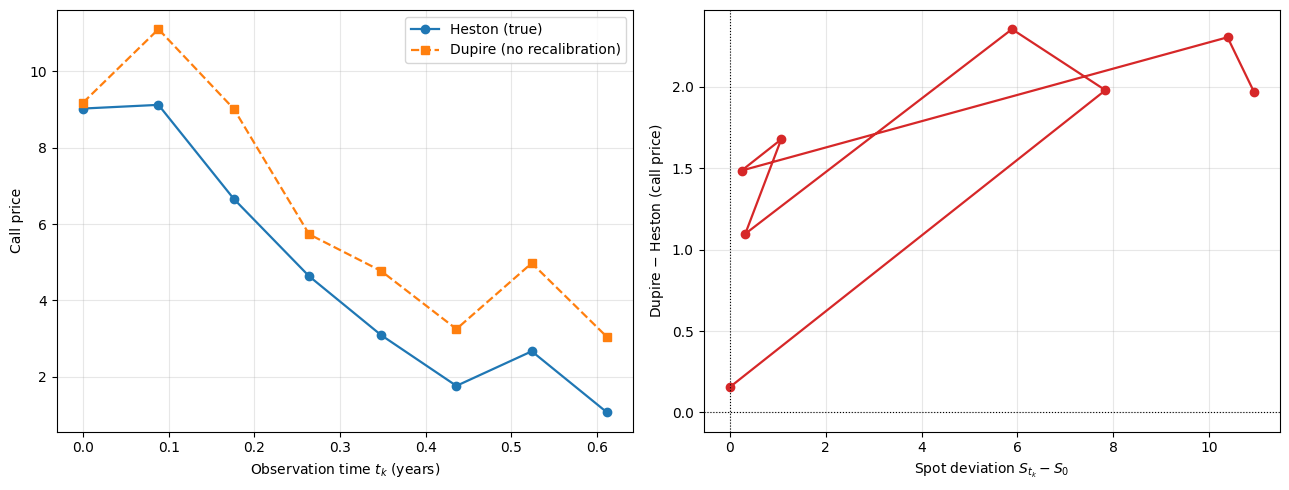

In [22]:
# Single-path comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(obs_t, heston_prices, "o-", lw=1.6, label="Heston (true)")
axes[0].plot(obs_t, dupire_prices, "s--", lw=1.6, label="Dupire (no recalibration)")
axes[0].set_xlabel("Observation time $t_k$ (years)")
axes[0].set_ylabel("Call price")
axes[0].legend(); axes[0].grid(alpha=0.3)

spot_dev = obs_S - S0
axes[1].plot(spot_dev, errors, "o-", lw=1.6, color="C3")
axes[1].axhline(0, color="k", ls=":", lw=0.8)
axes[1].axvline(0, color="k", ls=":", lw=0.8)
axes[1].set_xlabel(r"Spot deviation $S_{t_k} - S_0$")
axes[1].set_ylabel("Dupire $-$ Heston (call price)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("dupire_repricing_comparison.png", dpi=300)
plt.show()

In [23]:
def repricing_error_statistics(n_paths_used, t_grid_paths, S_paths, V_paths,
                               T_star, K_star, n_observations, sigma_loc,
                               r, kappa, theta, xi, rho):
    """Aggregate Dupire-vs-Heston re-pricing errors across multiple paths."""
    if n_paths_used > S_paths.shape[0]:
        raise ValueError(f"Asked for {n_paths_used} paths but only "
                         f"{S_paths.shape[0]} simulated.")

    obs_times = np.linspace(0.0, T_star, n_observations + 1)[:-1]
    obs_indices = np.array(
        [int(np.argmin(np.abs(t_grid_paths - tt))) for tt in obs_times]
    )
    obs_t = t_grid_paths[obs_indices]

    H = np.empty((n_paths_used, n_observations))
    D = np.empty((n_paths_used, n_observations))
    for p in range(n_paths_used):
        for k, idx in enumerate(obs_indices):
            S_k, V_k, t_k = S_paths[p, idx], V_paths[p, idx], t_grid_paths[idx]
            H[p, k] = heston_call_price_at_state(
                S_k, V_k, K_star, T_star - t_k, r, kappa, theta, xi, rho,
            )
            D[p, k] = price_call_dupire_pde_from(
                t_k, S_k, K_star, T_star, r, sigma_loc,
            )
    return obs_t, H, D, D - H


n_paths_used = 200
obs_t, H_all, D_all, err_all = repricing_error_statistics(
    n_paths_used, t, S_paths, V_paths,
    T_star, K_star, n_observations, sigma_loc,
    r, kappa, theta, xi, rho,
)

mean_err   = err_all.mean(axis=0)
std_err    = err_all.std(axis=0)
median_err = np.median(err_all, axis=0)
q05, q95   = np.percentile(err_all, [5, 95], axis=0)

print(f"Repricing errors across {n_paths_used} paths:")
print(f"{'t_k':>6} {'mean':>9} {'median':>9} {'std':>9} {'5%':>9} {'95%':>9}")
print("-" * 60)
for k in range(n_observations):
    print(f"{obs_t[k]:>6.3f} {mean_err[k]:>+9.4f} {median_err[k]:>+9.4f} "
          f"{std_err[k]:>9.4f} {q05[k]:>+9.4f} {q95[k]:>+9.4f}")

Repricing errors across 200 paths:
   t_k      mean    median       std        5%       95%
------------------------------------------------------------
 0.000   +0.1556   +0.1556    0.0000   +0.1556   +0.1556
 0.088   -0.0073   +0.0846    1.1906   -2.0076   +1.7458
 0.176   -0.0958   +0.1122    1.4956   -2.5228   +2.0665
 0.264   -0.0659   +0.1026    1.4933   -2.6089   +2.0746
 0.348   -0.0996   +0.0438    1.4577   -2.6519   +1.9253
 0.436   -0.0465   +0.0054    1.1432   -1.9673   +1.8124
 0.524   -0.0441   -0.0146    1.0417   -1.7015   +1.6958
 0.612   -0.0760   +0.0000    0.7796   -1.5313   +1.0577


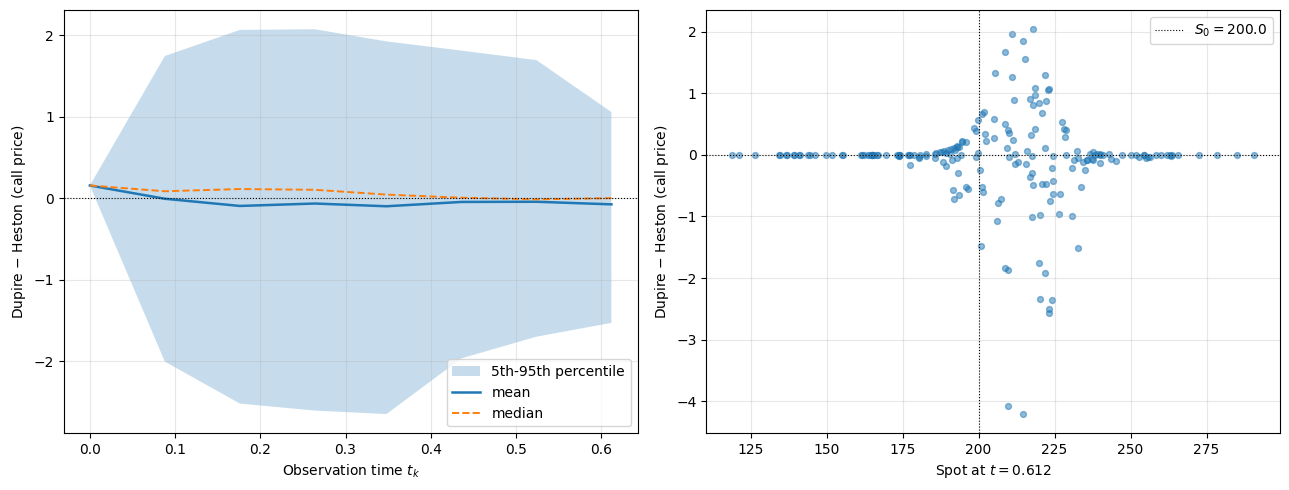

In [24]:
# Aggregate error plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].fill_between(obs_t, q05, q95, alpha=0.25, label="5th-95th percentile")
axes[0].plot(obs_t, mean_err, lw=1.8, label="mean")
axes[0].plot(obs_t, median_err, lw=1.4, ls="--", label="median")
axes[0].axhline(0, color="k", ls=":", lw=0.8)
axes[0].set_xlabel("Observation time $t_k$")
axes[0].set_ylabel("Dupire $-$ Heston (call price)")
# axes[0].set_title(f"Repricing error across {n_paths_used} paths")
axes[0].legend(); axes[0].grid(alpha=0.3)

final_idx = -1
final_idx_path = int(np.argmin(np.abs(t - obs_t[final_idx])))
final_S = S_paths[:n_paths_used, final_idx_path]
axes[1].scatter(final_S, err_all[:, final_idx], alpha=0.5, s=18)
axes[1].axhline(0, color="k", ls=":", lw=0.8)
axes[1].axvline(S0, color="k", ls=":", lw=0.8, label=f"$S_0 = {S0}$")
axes[1].set_xlabel(rf"Spot at $t = {obs_t[final_idx]:.3f}$")
axes[1].set_ylabel("Dupire $-$ Heston (call price)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("dupire_repricing_error_analysis.png", dpi=300)
plt.show()

## Task 6: Blind Heston calibration

In [25]:
def black_scholes_vega(S, K, T, r, sigma):
    """BS vega dC/dsigma. Used as a weight in the calibration loss."""
    if T <= 0 or sigma <= 0:
        return 0.0
    sqrt_T = np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrt_T)
    return S * norm.pdf(d1) * sqrt_T


def heston_call_surface(params, T_grid, K_grid, S0, r, eval_date=None):
    """Price the (T_grid x K_grid) call surface for parameter vector (V0, kappa, theta, xi, rho).

    Returns NaN-filled array if any parameter is inadmissible, so the optimiser
    can detect and steer away from the boundary.
    """
    V0, kappa_, theta_, xi_, rho_ = params
    if V0 <= 0 or kappa_ <= 0 or theta_ <= 0 or xi_ <= 0 or not -1.0 < rho_ < 1.0:
        return np.full((len(T_grid), len(K_grid)), np.nan)

    if eval_date is None:
        eval_date = ql.Settings.instance().evaluationDate
    day_count = ql.Actual365Fixed()
    rate_handle = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, r, day_count))
    div_handle = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, 0.0, day_count))
    spot_handle = ql.QuoteHandle(ql.SimpleQuote(S0))

    proc = ql.HestonProcess(rate_handle, div_handle, spot_handle,
                             V0, kappa_, theta_, xi_, rho_)
    engine = ql.AnalyticHestonEngine(ql.HestonModel(proc))

    surface = np.empty((len(T_grid), len(K_grid)))
    for i, T in enumerate(T_grid):
        n_days = int(round(T * 365))
        maturity = eval_date + ql.Period(n_days, ql.Days)
        exercise = ql.EuropeanExercise(maturity)
        for j, K in enumerate(K_grid):
            payoff = ql.PlainVanillaPayoff(ql.Option.Call, K)
            opt = ql.VanillaOption(payoff, exercise)
            opt.setPricingEngine(engine)
            surface[i, j] = opt.NPV()
    return surface


def calibration_residuals(params, T_grid, K_grid, S0, r, target_prices, target_iv):
    """Vega-weighted residuals on the price surface, flattened for least_squares."""
    model_prices = heston_call_surface(params, T_grid, K_grid, S0, r)
    weights = np.zeros_like(target_prices)
    valid = ~np.isnan(target_iv) & (target_iv > 0)
    K_mesh = np.broadcast_to(K_grid[None, :], target_prices.shape)
    T_mesh = np.broadcast_to(T_grid[:, None], target_prices.shape)
    for idx in np.argwhere(valid):
        i, j = idx
        v = black_scholes_vega(S0, K_mesh[i, j], T_mesh[i, j], r, target_iv[i, j])
        if v > 1e-6:
            weights[i, j] = 1.0 / v
    residuals = (model_prices - target_prices) * weights
    residuals = np.where(np.isnan(residuals), 1e6, residuals)
    return residuals.ravel()

In [26]:
def calibrate_heston(target_prices, target_iv, T_grid, K_grid, S0, r,
                     initial_guesses=None, verbose=True):
    """Multi-start Levenberg-Marquardt calibration of Heston parameters."""
    if initial_guesses is None:
        initial_guesses = [
            (0.04, 1.0, 0.04, 0.30, -0.50),
            (0.06, 2.0, 0.06, 0.50, -0.70),
            (0.02, 0.5, 0.05, 0.20, -0.30),
            (0.08, 3.0, 0.03, 0.40, -0.80),
        ]

    best = None
    for k, x0 in enumerate(initial_guesses):
        try:
            t0 = time.time()
            res = least_squares(
                calibration_residuals,
                x0=np.asarray(x0, dtype=float),
                args=(T_grid, K_grid, S0, r, target_prices, target_iv),
                method="lm", max_nfev=400, xtol=1e-10, ftol=1e-10,
            )
            elapsed = time.time() - t0
            cost = 0.5 * np.sum(res.fun ** 2)
            if verbose:
                print(f"  seed {k}: cost = {cost:.6e}  ({res.nfev} fev, "
                      f"{elapsed:.1f}s, status={res.status})")
            if best is None or cost < best["cost"]:
                best = {"cost": cost, "params": res.x, "result": res, "seed": k}
        except Exception as exc:
            if verbose:
                print(f"  seed {k}: failed ({exc})")
    if best is None:
        raise RuntimeError("All calibration attempts failed.")
    return best


# Add 0.5% multiplicative Gaussian noise to the target prices, matching a realistic
# bid-ask spread for liquid equity index options. The noiseless surface gives perfect
# recovery and is uninformative.
np.random.seed(123)
noise_level = 0.005
target_prices_noisy = prices * (1.0 + noise_level * np.random.standard_normal(prices.shape))
target_prices_noisy = np.clip(
    target_prices_noisy,
    np.maximum(S0 - K_grid[None, :] * np.exp(-r * T_grid[:, None]), 0.0),
    S0,
)

# Re-derive IV from the noisy prices so the vega weighting matches the noisy targets
target_iv_noisy = np.full_like(target_prices_noisy, np.nan)
for i in range(len(T_grid)):
    for j in range(len(K_grid)):
        target_iv_noisy[i, j] = implied_volatility_otm(
            target_prices_noisy[i, j], S0, K_grid[j], T_grid[i], r,
        )
n_iv_failed = int(np.isnan(target_iv_noisy).sum())
print(f"Noisy target prepared: noise = {noise_level*100:.2f}%, "
      f"{n_iv_failed} cells failed IV inversion (zero-weighted).\n")

print("Calibrating blind Heston model against the noisy price surface...")
calib = calibrate_heston(target_prices_noisy, target_iv_noisy, T_grid, K_grid, S0, r)

V0_b, kappa_b, theta_b, xi_b, rho_b = calib["params"]
print(f"\nBest fit (seed {calib['seed']}, cost = {calib['cost']:.4e}):")
print(f"{'param':>6} {'true':>10} {'calibrated':>12} {'rel diff':>10}")
print("-" * 42)
truth = {"V0": nu0, "kappa": kappa, "theta": theta, "xi": xi, "rho": rho}
fit   = {"V0": V0_b, "kappa": kappa_b, "theta": theta_b, "xi": xi_b, "rho": rho_b}
for name in ("V0", "kappa", "theta", "xi", "rho"):
    t_, f_ = truth[name], fit[name]
    rel = (f_ - t_) / abs(t_) * 100 if abs(t_) > 1e-12 else float("nan")
    print(f"{name:>6} {t_:>10.4f} {f_:>12.4f} {rel:>+9.2f}%")

Noisy target prepared: noise = 0.50%, 106 cells failed IV inversion (zero-weighted).

Calibrating blind Heston model against the noisy price surface...
  seed 0: cost = 3.798881e-01  (132 fev, 24.1s, status=4)
  seed 1: cost = 3.799238e-01  (191 fev, 33.2s, status=2)
  seed 2: cost = 3.798975e-01  (116 fev, 21.0s, status=4)
  seed 3: cost = 3.798750e-01  (204 fev, 35.3s, status=2)

Best fit (seed 3, cost = 3.7988e-01):
 param       true   calibrated   rel diff
------------------------------------------
    V0     0.0400       0.0387     -3.27%
 kappa     1.5000       0.9514    -36.57%
 theta     0.0400       0.0390     -2.60%
    xi     0.3000       0.1859    -38.03%
   rho    -0.7000      -0.8033    -14.75%


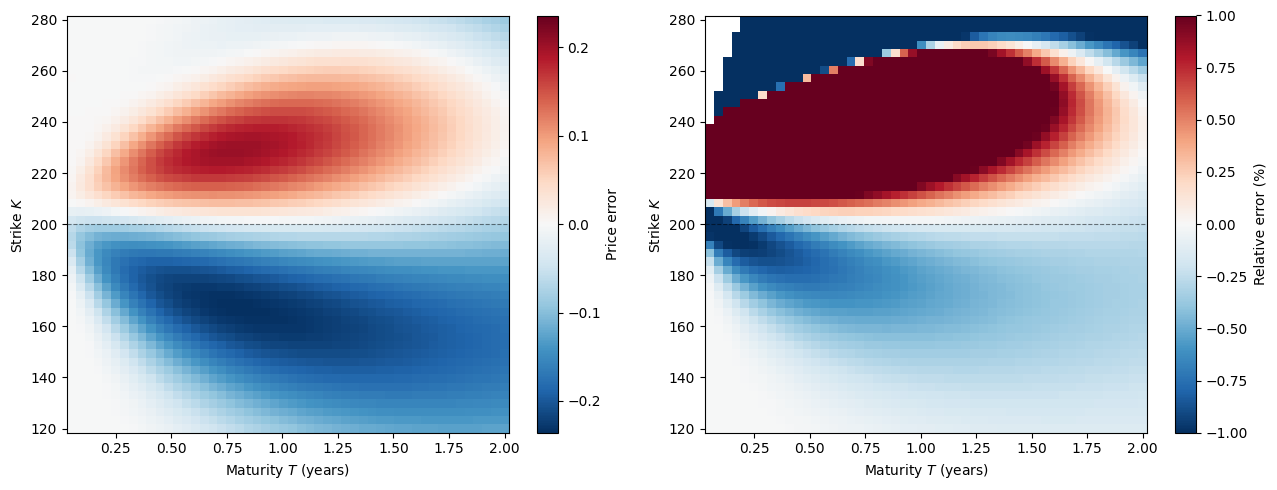

Max absolute error  : 0.2359
Mean absolute error : 0.0995
Max relative error  : 92.0430%


In [27]:
# Calibration error against the true (noiseless) surface
calibrated_prices = heston_call_surface(calib["params"], T_grid, K_grid, S0, r)
abs_err = calibrated_prices - prices
rel_err = abs_err / np.where(prices > 1e-6, prices, np.nan) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mesh1 = axes[0].pcolormesh(T_grid, K_grid, abs_err.T,
                           cmap="RdBu_r", shading="auto",
                           vmin=-np.nanmax(np.abs(abs_err)),
                           vmax=np.nanmax(np.abs(abs_err)))
axes[0].axhline(S0, color="k", ls="--", lw=0.8, alpha=0.5)
axes[0].set_xlabel("Maturity $T$ (years)")
axes[0].set_ylabel("Strike $K$")
# axes[0].set_title("Calibrated $-$ target price (absolute)")
fig.colorbar(mesh1, ax=axes[0], label="Price error")

mesh2 = axes[1].pcolormesh(T_grid, K_grid, rel_err.T,
                           cmap="RdBu_r", shading="auto", vmin=-1, vmax=1)
axes[1].axhline(S0, color="k", ls="--", lw=0.8, alpha=0.5)
axes[1].set_xlabel("Maturity $T$ (years)")
axes[1].set_ylabel("Strike $K$")
fig.colorbar(mesh2, ax=axes[1], label="Relative error (%)")

plt.tight_layout()
plt.savefig("heston_calibration_error.png", dpi=300)
plt.show()

print(f"Max absolute error  : {np.nanmax(np.abs(abs_err)):.4f}")
print(f"Mean absolute error : {np.nanmean(np.abs(abs_err)):.4f}")
print(f"Max relative error  : {np.nanmax(np.abs(rel_err)):.4f}%")

In [28]:
def heston_repricing_with_params(params, t_grid_paths, S_paths, V_paths,
                                 obs_t, T_star, K_star, r, path_index=0):
    """Re-price the option along a path using the supplied Heston parameters."""
    V0_p, kappa_p, theta_p, xi_p, rho_p = params
    obs_indices = np.array(
        [int(np.argmin(np.abs(t_grid_paths - tt))) for tt in obs_t]
    )
    out = np.empty(len(obs_t))
    for k, idx in enumerate(obs_indices):
        S_k, V_k, t_k = S_paths[path_index, idx], V_paths[path_index, idx], t_grid_paths[idx]
        out[k] = heston_call_price_at_state(
            S_k, V_k, K_star, T_star - t_k, r,
            kappa_p, theta_p, xi_p, rho_p,
        )
    return out


# Single-path re-pricing: truth, blind Heston, Dupire (all without recalibration after t=0)
obs_t, obs_S, obs_V = select_observation_path(
    t, S_paths, V_paths, T_star, n_observations=n_observations, path_index=path_index,
)
truth_path = heston_repricing_with_params(
    (nu0, kappa, theta, xi, rho),
    t, S_paths, V_paths, obs_t, T_star, K_star, r, path_index=path_index,
)
blind_path = heston_repricing_with_params(
    calib["params"],
    t, S_paths, V_paths, obs_t, T_star, K_star, r, path_index=path_index,
)
dupire_path = np.array([
    price_call_dupire_pde_from(t_k, S_k, K_star, T_star, r, sigma_loc)
    for t_k, S_k in zip(obs_t, obs_S)
])

print(f"{'t_k':>6} {'Heston (true)':>14} {'Blind Heston':>14} "
      f"{'Dupire':>10} {'Blind err':>10} {'Dupire err':>11}")
print("-" * 75)
for k in range(len(obs_t)):
    print(f"{obs_t[k]:>6.3f} {truth_path[k]:>14.4f} "
          f"{blind_path[k]:>14.4f} {dupire_path[k]:>10.4f} "
          f"{blind_path[k] - truth_path[k]:>+10.4f} "
          f"{dupire_path[k] - truth_path[k]:>+11.4f}")

   t_k  Heston (true)   Blind Heston     Dupire  Blind err  Dupire err
---------------------------------------------------------------------------
 0.000         9.0203         9.3267     9.1759    +0.3064     +0.1556
 0.088         9.1170         8.7693    11.0970    -0.3477     +1.9800
 0.176         6.6569         6.3907     9.0121    -0.2662     +2.3552
 0.264         4.6333         4.7759     5.7310    +0.1426     +1.0977
 0.348         3.0946         3.1568     4.7723    +0.0622     +1.6776
 0.436         1.7660         1.8461     3.2523    +0.0801     +1.4863
 0.524         2.6707         2.5969     4.9759    -0.0738     +2.3052
 0.612         1.0696         1.0571     3.0417    -0.0124     +1.9721


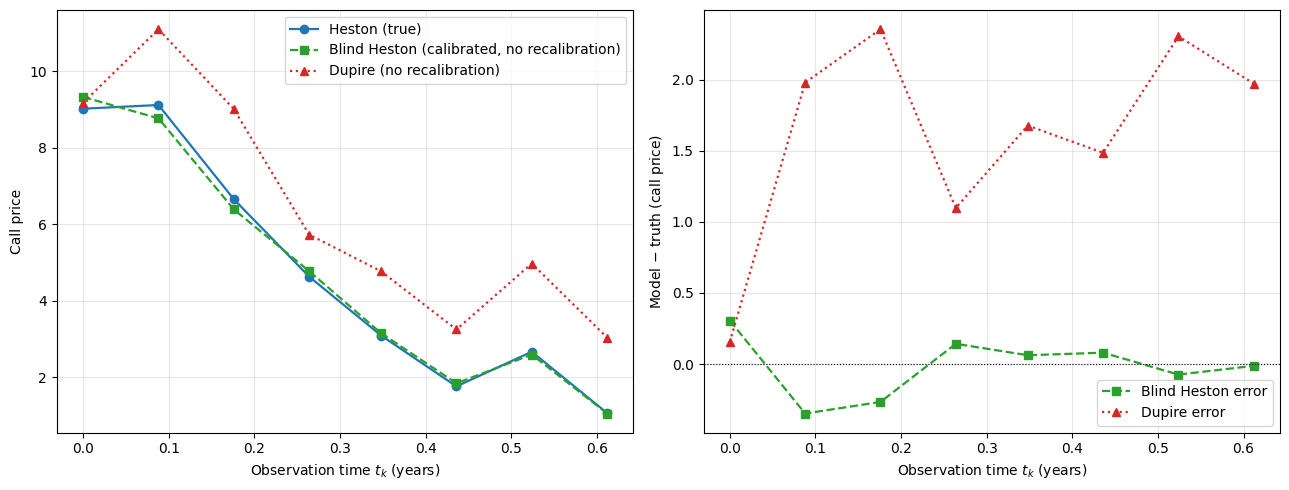

In [29]:
# Single-path comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(obs_t, truth_path, "o-", lw=1.6, label="Heston (true)", color="C0")
axes[0].plot(obs_t, blind_path, "s--", lw=1.6,
             label="Blind Heston (calibrated, no recalibration)", color="C2")
axes[0].plot(obs_t, dupire_path, "^:", lw=1.6,
             label="Dupire (no recalibration)", color="C3")
axes[0].set_xlabel("Observation time $t_k$ (years)")
axes[0].set_ylabel("Call price")
# axes[0].set_title(f"Re-pricing $(T^*, K^*) = ({T_star}, {K_star})$ on one path")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(obs_t, blind_path - truth_path, "s--", lw=1.6,
             label="Blind Heston error", color="C2")
axes[1].plot(obs_t, dupire_path - truth_path, "^:", lw=1.6,
             label="Dupire error", color="C3")
axes[1].axhline(0, color="k", ls=":", lw=0.8)
axes[1].set_xlabel("Observation time $t_k$ (years)")
axes[1].set_ylabel("Model $-$ truth (call price)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("heston_dupire_repricing_comparison.png", dpi=300)
plt.show()

In [30]:
def aggregate_repricing_errors(n_paths_used, t_grid_paths, S_paths, V_paths,
                               T_star, K_star, n_observations,
                               sigma_loc, calibrated_params,
                               r, kappa, theta, xi, rho):
    """Aggregate truth, blind-Heston and Dupire prices across paths."""
    obs_t = np.linspace(0.0, T_star, n_observations + 1)[:-1]
    obs_indices = np.array(
        [int(np.argmin(np.abs(t_grid_paths - tt))) for tt in obs_t]
    )
    H_true  = np.empty((n_paths_used, n_observations))
    H_blind = np.empty((n_paths_used, n_observations))
    D       = np.empty((n_paths_used, n_observations))

    V0_b, kappa_b, theta_b, xi_b, rho_b = calibrated_params
    for p in range(n_paths_used):
        for k, idx in enumerate(obs_indices):
            S_k, V_k, t_k = S_paths[p, idx], V_paths[p, idx], t_grid_paths[idx]
            T_rem = T_star - t_k
            H_true[p, k]  = heston_call_price_at_state(
                S_k, V_k, K_star, T_rem, r, kappa, theta, xi, rho,
            )
            H_blind[p, k] = heston_call_price_at_state(
                S_k, V_k, K_star, T_rem, r, kappa_b, theta_b, xi_b, rho_b,
            )
            D[p, k] = price_call_dupire_pde_from(
                t_k, S_k, K_star, T_star, r, sigma_loc,
            )
    return obs_t, H_true, H_blind, D


obs_t_agg, H_true, H_blind, D_agg = aggregate_repricing_errors(
    n_paths_used, t, S_paths, V_paths,
    T_star, K_star, n_observations,
    sigma_loc, calib["params"],
    r, kappa, theta, xi, rho,
)

err_blind  = H_blind - H_true
err_dupire = D_agg   - H_true
rmse_blind  = np.sqrt(np.mean(err_blind  ** 2, axis=0))
rmse_dupire = np.sqrt(np.mean(err_dupire ** 2, axis=0))
mae_blind   = np.mean(np.abs(err_blind),  axis=0)
mae_dupire  = np.mean(np.abs(err_dupire), axis=0)

print(f"{'t_k':>6} {'RMSE blind':>12} {'RMSE Dupire':>12} "
      f"{'MAE blind':>11} {'MAE Dupire':>11}")
print("-" * 60)
for k in range(len(obs_t_agg)):
    print(f"{obs_t_agg[k]:>6.3f} "
          f"{rmse_blind[k]:>12.4f} {rmse_dupire[k]:>12.4f} "
          f"{mae_blind[k]:>11.4f} {mae_dupire[k]:>11.4f}")

   t_k   RMSE blind  RMSE Dupire   MAE blind  MAE Dupire
------------------------------------------------------------
 0.000       0.3064       0.1556      0.3064      0.1556
 0.087       0.3845       1.1906      0.3274      0.9556
 0.175       0.3634       1.4986      0.3050      1.1786
 0.262       0.3059       1.4948      0.2598      1.1495
 0.350       0.2388       1.4611      0.2010      1.0637
 0.438       0.1628       1.1442      0.1337      0.7997
 0.525       0.1101       1.0426      0.0864      0.6474
 0.612       0.0406       0.7833      0.0275      0.4011
